# Time Series Foundations: When Order Matters

**DCS 404 · Data Science and Machine Learning**

---

Every dataset in this course so far has shared a quiet assumption. When we split the diabetes data with
`train_test_split(..., shuffle=True)`, we were saying something specific: *the rows are interchangeable*.
Patient 340 tells us nothing about patient 341 that patient 12 doesn't also tell us. Rows are independent
draws from one fixed distribution — **i.i.d.**, in the jargon — and shuffling them destroys nothing,
because there was no order to destroy.

Now consider monthly airline passenger counts from 1949 to 1960. Shuffle *those* rows and you have
vandalised the data. The whole point is that December 1959 comes after November 1959, that summers are
busier than winters, that the airline industry grew over the decade. The order **is** the signal.

A **time series** is a sequence of observations indexed by time, where that indexing carries information.
This one change — dropping independence — invalidates a surprising amount of what we have built. Random
train/test splits leak the future into the past. Cross-validation folds become time machines. Even
"compute the mean" becomes ambiguous, because the mean may be *moving*. In exchange, we gain a genuinely
new capability: **forecasting**, the business of saying something about observations that do not exist yet.

This module builds the vocabulary and the diagnostic toolkit. We will not fit a single ARIMA model here —
that is the next two modules. Instead we learn to *look* at a series properly: decompose it into the
forces that generated it, test whether it is stable enough to model, read its autocorrelation fingerprint,
and establish the honest baselines that any sophisticated model must beat. Skip this module and every
model in the next two will be a black box you cannot debug.

## How to work through this

The usual rhythm: run every code cell (`Shift + Enter`), study the output, *then* read the commentary.
Cells build on each other, so if something errors, run from the top.

The module is in three acts:

1. **Sections 1–3** are about *seeing*: what makes a series a series, how pandas handles time, and the
   four components (trend, seasonality, cycle, noise) that combine to make the shape you see.
2. **Sections 4–6** are the diagnostic toolkit: decomposition, **stationarity** and the transformations
   that buy it, and the **ACF/PACF** correlogram — the single most important plot in time series.
3. **Sections 7–8** close the loop: how to split time series data without cheating, the four **baseline
   forecasts**, and the error metrics that tell you whether anything fancier was worth it.

Our running dataset is the classic **Air Passengers** series (144 monthly totals, 1949–1960) — small
enough to read row by row, and it contains every phenomenon we need to name.

## Learning objectives

After completing this module you will be able to:

- Explain why **i.i.d.-based tooling** (shuffled splits, k-fold CV) is invalid for temporal data, and
  what replaces it.
- Manipulate time series in pandas using a **DatetimeIndex**, `asfreq`, `resample`, `shift`, and
  `rolling`.
- Identify the **components** of a series — trend, seasonality, cyclical, irregular — and distinguish
  **additive** from **multiplicative** composition.
- Decompose a series with `seasonal_decompose` and **STL**, and interpret each panel.
- Define **stationarity**, test for it with the **ADF** and **KPSS** tests, and induce it via **log
  transforms** and **differencing**.
- Read an **ACF** and **PACF** plot, recognise **white noise**, and use the correlogram to detect trend
  and seasonality.
- Produce **naive, seasonal naive, mean, and drift** forecasts, and evaluate them with **MAE, RMSE,
  MAPE** and **MASE**.

## Setup

Run this once. Libraries, plotting style, and the Air Passengers series loaded with a proper monthly
`DatetimeIndex`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")   # statsmodels is chatty about test-statistic interpolation

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

def load_csv(name, **kwargs):
    for candidate in [Path(f"data/{name}"), Path(f"notebooks/data/{name}")]:
        if candidate.exists():
            print(f"Loaded {name} from: {candidate}")
            return pd.read_csv(candidate, **kwargs)
    raise FileNotFoundError(f"Could not find {name}")

# Air Passengers: monthly totals (thousands), Jan 1949 - Dec 1960
air = load_csv("air_passengers.csv", parse_dates=["Month"], index_col="Month")
air = air.asfreq("MS")                     # MS = month start; declares the sampling frequency
passengers = air["Passengers"]

print(passengers.head())
print(f"\n{len(passengers)} observations from {passengers.index.min():%b %Y} "
      f"to {passengers.index.max():%b %Y}, frequency = {passengers.index.freqstr}")

Loaded air_passengers.csv from: data/air_passengers.csv
Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: Passengers, dtype: int64

144 observations from Jan 1949 to Dec 1960, frequency = MS


---
## 1. What breaks when order matters

Let us make the danger concrete rather than abstract. Here is the series, and here is what happens if we
treat it like every other dataset in this course.

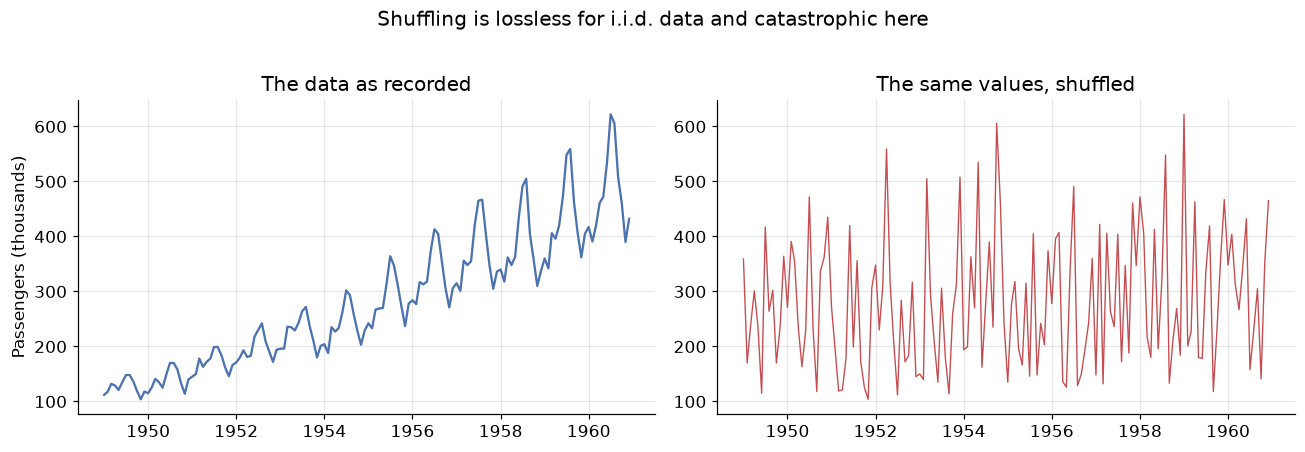

Mean, std, min, max are identical: 280.3 vs 280.3


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(passengers.index, passengers.values, color="C0")
axes[0].set_title("The data as recorded")
axes[0].set_ylabel("Passengers (thousands)")

shuffled = passengers.sample(frac=1, random_state=RANDOM_STATE).values
axes[1].plot(passengers.index, shuffled, color="C3", linewidth=0.9)
axes[1].set_title("The same values, shuffled")

for ax in axes:
    ax.set_xlabel("")
fig.suptitle("Shuffling is lossless for i.i.d. data and catastrophic here", y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean, std, min, max are identical: {shuffled.mean():.1f} vs {passengers.mean():.1f}")

Both panels contain *exactly the same 144 numbers*. Every summary statistic you learned in the first weeks
of this course — mean, variance, quantiles, the whole histogram — is identical between them. Yet the left
panel is forecastable and the right panel is noise. **All of the information destroyed by shuffling lived
in the ordering**, and none of our i.i.d. tooling can see it.

Three concrete consequences follow, and they will govern everything in these three modules:

1. **Random train/test splits leak the future.** If a randomly chosen test point sits at March 1955, the
   model trains on April 1955 — it has literally seen the future it is being asked to predict. Test scores
   come back beautiful and mean nothing. The split must be **chronological**: train on the past, test on
   the most recent block.

2. **K-fold cross-validation is invalid** for the same reason. Its replacement is **rolling-origin**
   (or "walk-forward") validation, where the training window only ever grows forwards in time.

3. **Observations are correlated with their own past.** This is not a nuisance to be cleaned away — it is
   the *resource*. Everything we forecast, we forecast because the past leaves fingerprints on the
   present. Section 6 is about reading those fingerprints.

---
## 2. Time series in pandas

Before the statistics, the mechanics. A time series in pandas is a `Series` whose index is a
`DatetimeIndex` — and once that is true, a large amount of temporal machinery unlocks. The important
extra step is declaring the **frequency**, which we did with `asfreq("MS")` in the setup cell. A series
that knows it is monthly can tell you what "one lag ago" means; one that doesn't, can't.

Four operations carry most of the work.

### Selecting by time

You can slice with strings, and pandas does the parsing.

In [3]:
print("Whole year 1950:")
print(passengers["1950"].values)

print("\nA date range (partial-string slicing is inclusive on both ends):")
print(passengers["1959-10":"1960-02"])

Whole year 1950:
[115 126 141 135 125 149 170 170 158 133 114 140]

A date range (partial-string slicing is inclusive on both ends):
Month
1959-10-01    407
1959-11-01    362
1959-12-01    405
1960-01-01    417
1960-02-01    391
Freq: MS, Name: Passengers, dtype: int64


### `shift` — moving the past into the present

`shift(k)` slides the series forward by `k` steps, which lines up each observation with the value from
$k$ periods earlier. This is how *lag features* are built, and it is the mechanical heart of every
autoregressive model in Module 12.

In [4]:
lags = pd.DataFrame({
    "y_t":     passengers,
    "y_{t-1}": passengers.shift(1),      # last month
    "y_{t-12}": passengers.shift(12),    # same month last year
})
print(lags.head(14))

# Correlation of the series with its own past
print(f"\nCorrelation with 1-month lag:  {lags['y_t'].corr(lags['y_{t-1}']):.3f}")
print(f"Correlation with 12-month lag: {lags['y_t'].corr(lags['y_{t-12}']):.3f}")

            y_t  y_{t-1}  y_{t-12}
Month                             
1949-01-01  112      NaN       NaN
1949-02-01  118    112.0       NaN
1949-03-01  132    118.0       NaN
1949-04-01  129    132.0       NaN
1949-05-01  121    129.0       NaN
1949-06-01  135    121.0       NaN
1949-07-01  148    135.0       NaN
1949-08-01  148    148.0       NaN
1949-09-01  136    148.0       NaN
1949-10-01  119    136.0       NaN
1949-11-01  104    119.0       NaN
1949-12-01  118    104.0       NaN
1950-01-01  115    118.0     112.0
1950-02-01  126    115.0     118.0

Correlation with 1-month lag:  0.960
Correlation with 12-month lag: 0.991


Both correlations are enormous — 0.96 and 0.99. Note that the *12-month* lag is the stronger of the two:
this month resembles the same month last year even more than it resembles last month. That is seasonality
showing up as a number. In an i.i.d. dataset a feature correlating 0.99
with the target would be a triumph; here it is simply what time series *are*. This self-correlation is
called **autocorrelation** and Section 6 measures it properly.

### `resample` — changing the time granularity

Resampling is a `groupby` over time. Going to a *coarser* frequency (monthly → yearly) requires an
aggregation; going *finer* requires an interpolation rule.

In [5]:
yearly = passengers.resample("YE").sum()          # YE = year end
print("Annual totals:")
print(yearly.astype(int).to_string())
print(f"\nGrowth 1949 -> 1960: {yearly.iloc[-1] / yearly.iloc[0]:.2f}x")

Annual totals:
Month
1949-12-31    1520
1950-12-31    1676
1951-12-31    2042
1952-12-31    2364
1953-12-31    2700
1954-12-31    2867
1955-12-31    3408
1956-12-31    3939
1957-12-31    4421
1958-12-31    4572
1959-12-31    5140
1960-12-31    5714
Freq: YE-DEC

Growth 1949 -> 1960: 3.76x


### `rolling` — the moving window

A rolling window computes a statistic over the last $w$ observations, sliding forward one step at a time.
A rolling *mean* is the simplest smoother in existence and our first look at the trend.

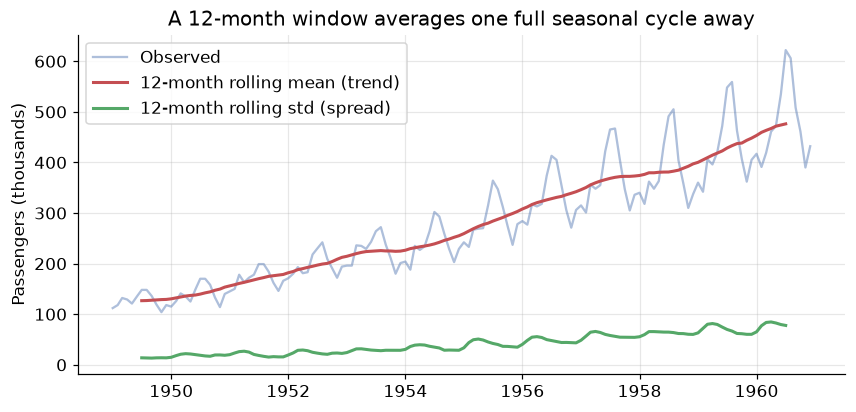

In [6]:
fig, ax = plt.subplots()
ax.plot(passengers, color="C0", alpha=0.45, label="Observed")
ax.plot(passengers.rolling(window=12, center=True).mean(), color="C3", lw=2,
        label="12-month rolling mean (trend)")
ax.plot(passengers.rolling(window=12, center=True).std(), color="C2", lw=2,
        label="12-month rolling std (spread)")
ax.set_title("A 12-month window averages one full seasonal cycle away")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
plt.show()

Two readings from this one plot, and both matter later:

- The red curve — the rolling mean — climbs steadily. That is the **trend**, and the fact that the
  average level changes over time already tells us the series is *not* stationary (Section 5).
- The green curve — the rolling standard deviation — also climbs. The series is not just drifting
  upwards, it is getting **noisier in absolute terms** as it grows. That specific pattern is the
  signature of *multiplicative* structure, which is the subject of the next section.

Note the choice of `window=12`. Averaging over exactly one full seasonal cycle causes the seasonal
ups and downs to cancel, leaving the trend behind. This trick is precisely how classical decomposition
works.

---
## 3. The four components

The classical view is that any time series is a superposition of four forces. Separating them is the
first analytical move you make, because different components need different treatment.

| Component | Symbol | What it is | Air Passengers example |
|---|---|---|---|
| **Trend** | $T_t$ | Long-run increase or decrease in the level | Air travel roughly tripled over the decade |
| **Seasonality** | $S_t$ | A pattern of **fixed, known period** | Summer peaks every single year |
| **Cyclical** | $C_t$ | Rises and falls of **no fixed period**, usually multi-year | Business cycles, recessions |
| **Irregular** | $e_t$ | What is left: unpredictable noise | Strikes, weather, measurement error |

The distinction between **seasonal** and **cyclical** trips up nearly everyone, so state it precisely:
seasonality has a *fixed and known* period (12 months, 7 days, 24 hours) and is tied to the calendar; a
cycle has *variable* duration and unknown timing. Christmas is seasonal; a recession is cyclical. Because
cycles are so hard to pin down, most practical modelling folds $C_t$ into the trend and speaks of three
components — **trend, seasonality, residual** — which is what `seasonal_decompose` reports.

### Additive or multiplicative?

How do the components combine? There are two candidate models:

$$\text{Additive:}\quad y_t = T_t + S_t + e_t \qquad\qquad \text{Multiplicative:}\quad y_t = T_t \times S_t \times e_t$$

In the **additive** case the seasonal swing is a *constant number of units* — the December bump is
$+40{,}000$ passengers whether the airline is small or large. In the **multiplicative** case the swing is
a *constant percentage* — December is always $+25\%$ above trend, so the absolute bump grows as the
airline grows.

The diagnostic is visual, and it is the one you saw in the rolling-std plot: **if the seasonal
oscillations widen as the level rises, the series is multiplicative.**

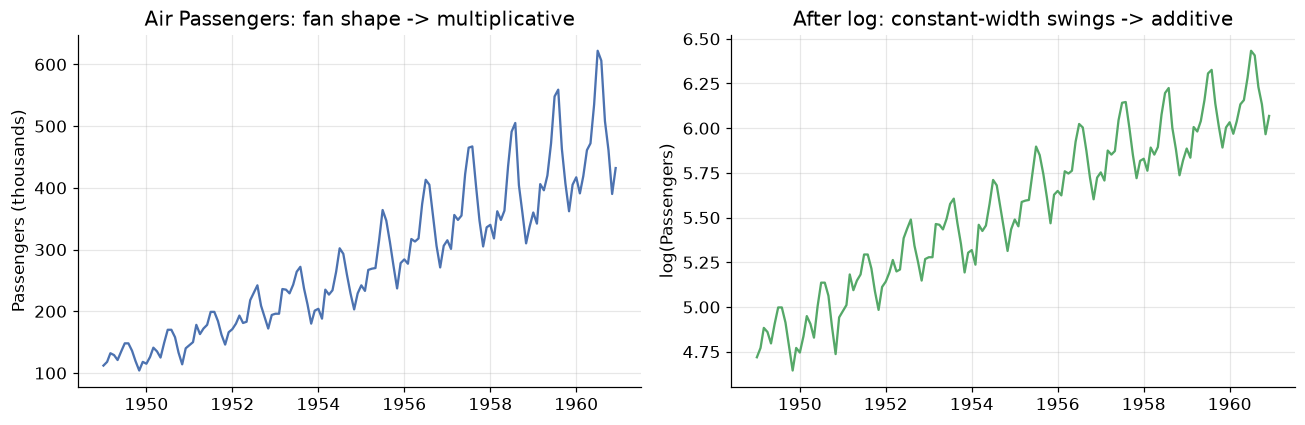

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(passengers, color="C0")
axes[0].set_title("Air Passengers: fan shape -> multiplicative")
axes[0].set_ylabel("Passengers (thousands)")

# The same series with the growth removed, for contrast
axes[1].plot(np.log(passengers), color="C2")
axes[1].set_title("After log: constant-width swings -> additive")
axes[1].set_ylabel("log(Passengers)")
plt.tight_layout()
plt.show()

The left panel fans outwards: the 1949 seasonal wobble is a few thousand passengers, the 1960 wobble is
over a hundred thousand. The right panel — the same data on a log scale — has swings of near-constant
height.

That is not a coincidence, it is algebra. Taking logs turns products into sums:

$$\log(T_t \times S_t \times e_t) = \log T_t + \log S_t + \log e_t$$

**A multiplicative series becomes additive under a log transform.** This is the single most useful
transformation in time series work, and we will lean on it repeatedly: rather than build multiplicative
machinery, take logs, use the simpler additive machinery, and exponentiate the forecast back at the end.

---
## 4. Decomposition

Decomposition estimates the components and hands them back as separate series. The classical algorithm is
exactly the trick from Section 2:

1. Estimate the **trend** with a centred moving average of one full season's width.
2. **Detrend** the series (subtract, or divide, depending on the model).
3. Estimate the **seasonal** component by averaging the detrended values for each period position — every
   January together, every February together — then centre them.
4. The **residual** is whatever remains.

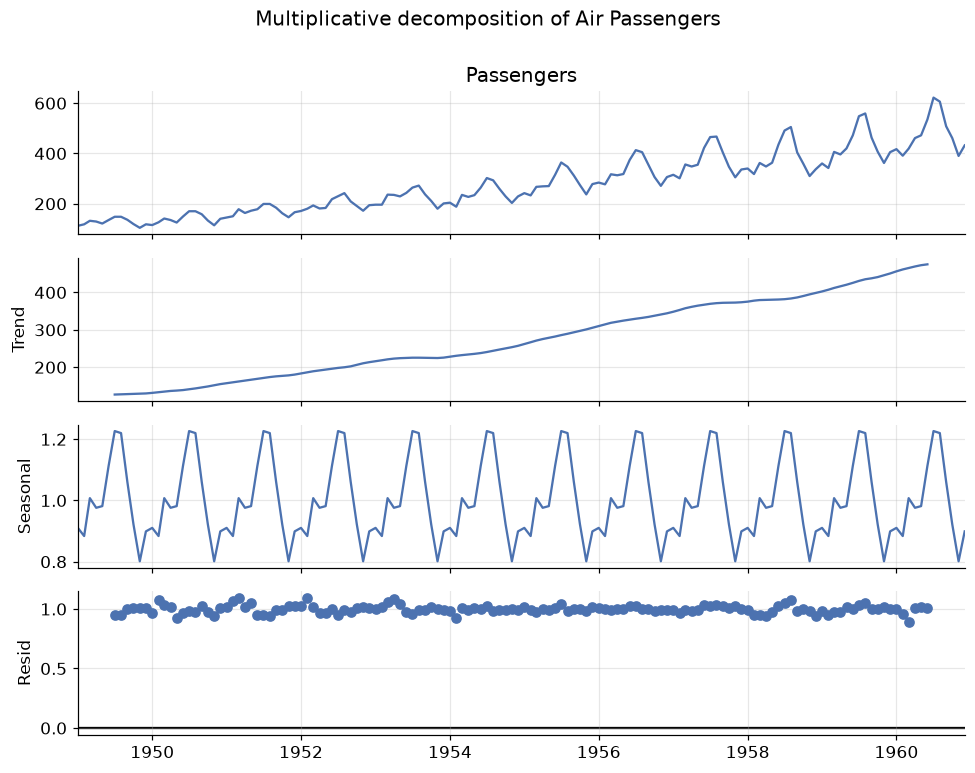

In [8]:
result = seasonal_decompose(passengers, model="multiplicative", period=12)

fig = result.plot()
fig.set_size_inches(9, 7)
fig.suptitle("Multiplicative decomposition of Air Passengers", y=1.00)
plt.tight_layout()
plt.show()

Read the four panels top to bottom:

- **Observed** — the raw series.
- **Trend** — a smooth, almost linear climb. Note it is *missing six months at each end*: a centred
  12-month window cannot be computed for the first and last half-window.
- **Seasonal** — a perfectly repeating shape. Because this is a multiplicative decomposition the values
  are *multipliers around 1.0*, so 1.25 means "25% above trend".
- **Residual** — what neither trend nor seasonality explains. **This panel is the diagnostic**: if it
  still has visible structure, your model has missed something.

Let us read the seasonal factors as numbers, because they are directly interpretable.

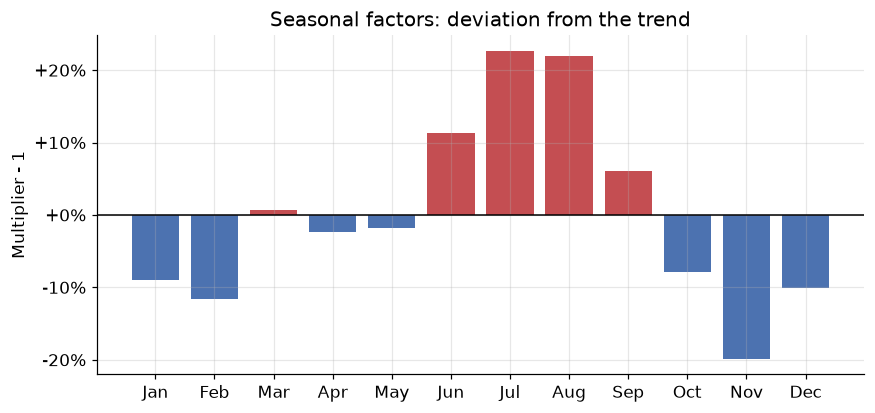

Busiest month:  July      (1.227 -> +22.7% vs trend)
Quietest month: November  (0.801 -> -19.9% vs trend)


In [9]:
seasonal_factors = result.seasonal.groupby(result.seasonal.index.month).mean()
seasonal_factors.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots()
colors = ["C3" if v > 1 else "C0" for v in seasonal_factors]
ax.bar(seasonal_factors.index, seasonal_factors - 1, color=colors)
ax.axhline(0, color="black", lw=1)
ax.set_title("Seasonal factors: deviation from the trend")
ax.set_ylabel("Multiplier - 1")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
plt.show()

print(f"Busiest month:  July      ({seasonal_factors['Jul']:.3f} -> {seasonal_factors['Jul']-1:+.1%} vs trend)")
print(f"Quietest month: November  ({seasonal_factors['Nov']:.3f} -> {seasonal_factors['Nov']-1:+.1%} vs trend)")

July and August run about 22–23% above trend, November about 20% below — a summer-holiday pattern that
anyone who has flown will find unsurprising. That is exactly the point: **a good decomposition should
produce components you can explain to a domain expert in plain language.** If the seasonal panel is
inexplicable, suspect the period is wrong.

### STL: the modern alternative

Classical decomposition has real weaknesses — it loses data at both ends, it forces the seasonal shape
to be *identical* every year, and outliers contaminate the trend. **STL** (Seasonal-Trend decomposition
using LOESS) fixes all three: it uses local regression, keeps every observation, and lets the seasonal
pattern evolve slowly.

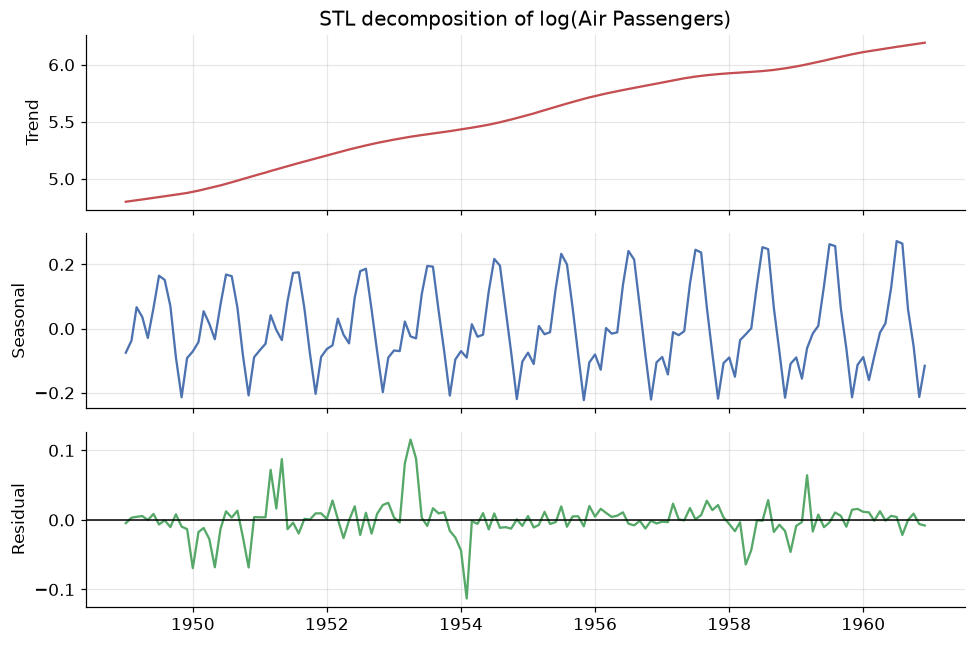

Residual std: 0.0265 (on the log scale, so ~2.7% of level)


In [10]:
stl = STL(np.log(passengers), period=12, robust=True).fit()

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(stl.trend, color="C3");    axes[0].set_ylabel("Trend")
axes[1].plot(stl.seasonal, color="C0"); axes[1].set_ylabel("Seasonal")
axes[2].plot(stl.resid, color="C2");    axes[2].set_ylabel("Residual")
axes[2].axhline(0, color="black", lw=1)
axes[0].set_title("STL decomposition of log(Air Passengers)")
plt.tight_layout()
plt.show()

print(f"Residual std: {stl.resid.std():.4f} (on the log scale, so ~{stl.resid.std():.1%} of level)")

We ran STL on the **log** of the series — the trick from Section 3 — which is why an additive method
handles this multiplicative data correctly. Look closely at the seasonal panel: the amplitude is *not*
quite constant, it grows subtly across the decade. Classical decomposition is incapable of representing
that; STL shows it to you.

`robust=True` down-weights outliers so a single strange month cannot bend the trend. Use it by default
on real data.

---
## 5. Stationarity

Here is the most important concept in the module, and the prerequisite for everything in Module 12.

A series is **stationary** if its statistical properties do not depend on *when* you look at it.
Formally, for **weak** (or covariance) stationarity we require three things:

1. **Constant mean:** $\mathbb{E}[y_t] = \mu$ for all $t$ — no trend.
2. **Constant variance:** $\mathrm{Var}(y_t) = \sigma^2$ for all $t$ — no change in volatility.
3. **Covariance depends only on the gap:** $\mathrm{Cov}(y_t, y_{t+k}) = \gamma_k$, a function of the lag
   $k$ alone, not of $t$ — the relationship between neighbours is the same in 1949 and 1960.

Why insist on this? Because **forecasting is the assumption that the future behaves like the past.** If a
series' behaviour keeps changing, then the pattern the model learned from 1949–1957 need not hold in 1960,
and there is nothing to extrapolate. Stationarity is the formal statement that the pattern is stable
enough to be worth learning. Every model in the ARIMA family requires it — the "I" in ARIMA exists
precisely to manufacture it.

Air Passengers fails all three conditions: the mean climbs, the variance grows, and the seasonal
structure means the correlation with a neighbouring month depends on *which* month. Let us confirm that
with a test rather than an eyeball.

### The Augmented Dickey-Fuller test

The **ADF test** checks for a *unit root* — the technical condition that makes a series wander without
returning to a fixed level. Its hypotheses are worth memorising, because the direction surprises people:

- $H_0$: the series **has a unit root** → it is **non-stationary**.
- $H_1$: the series is **stationary**.

So a **small p-value (< 0.05) means stationary**. A large p-value means you failed to reject
non-stationarity.

In [11]:
def adf_report(series, label):
    """Run the ADF test and print a verdict."""
    stat, pvalue, _, _, crit, _ = adfuller(series.dropna())
    verdict = "STATIONARY" if pvalue < 0.05 else "NON-STATIONARY"
    print(f"{label:<34} ADF = {stat:>7.3f}   p = {pvalue:.4f}   -> {verdict}")
    return pvalue

print("Augmented Dickey-Fuller  (H0 = non-stationary, so p < 0.05 means stationary)\n")
adf_report(passengers,                          "Raw series")
adf_report(np.log(passengers),                  "log(y)")
adf_report(np.log(passengers).diff(),           "log(y), 1st difference")
adf_report(np.log(passengers).diff().diff(12),  "log(y), 1st + seasonal difference")

Augmented Dickey-Fuller  (H0 = non-stationary, so p < 0.05 means stationary)

Raw series                         ADF =   0.815   p = 0.9919   -> NON-STATIONARY
log(y)                             ADF =  -1.717   p = 0.4224   -> NON-STATIONARY
log(y), 1st difference             ADF =  -2.717   p = 0.0711   -> NON-STATIONARY
log(y), 1st + seasonal difference  ADF =  -4.443   p = 0.0002   -> STATIONARY


np.float64(0.0002485912311384116)

That output is the whole story of how you prepare a series for modelling, in four lines.

- **Raw series**: p = 0.99. Wildly non-stationary, as expected.
- **After log**: still p ≈ 0.42. The log fixed the growing *variance* but did nothing about the growing
  *mean* — logs stabilise spread, not level.
- **After first differencing**: p ≈ 0.07. Big improvement, borderline. **Differencing** means modelling
  the *change* rather than the level: $\nabla y_t = y_t - y_{t-1}$. A series with a linear trend has
  differences with no trend at all.
- **After also seasonal differencing**: p = 0.0002. Comfortably stationary. **Seasonal differencing**,
  $\nabla_{12} y_t = y_t - y_{t-12}$, subtracts the same month last year, annihilating a fixed annual
  pattern.

The number of differences needed has a name and will become a model parameter: $d$ for ordinary
differencing, $D$ for seasonal. Air Passengers is a $d=1, D=1$ series — which, as you will see in Module
12, is exactly the famous "airline model".

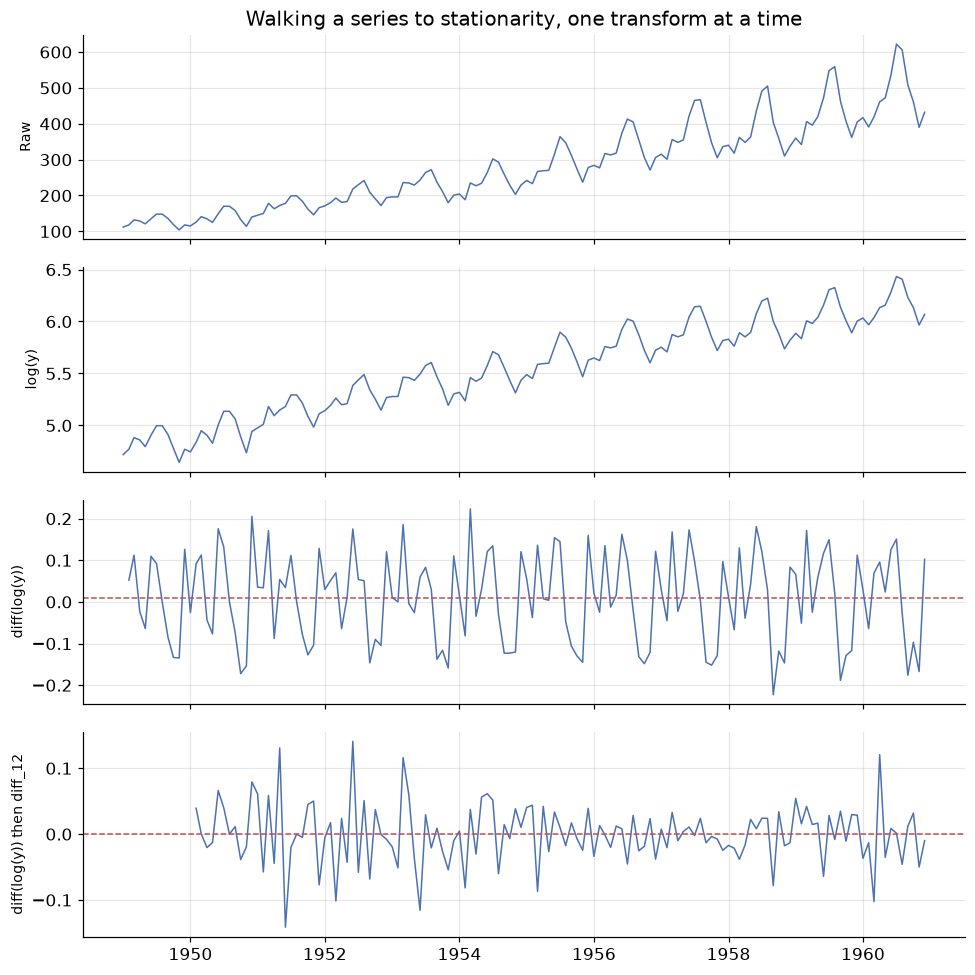

In [12]:
transforms = {
    "Raw":                        passengers,
    "log(y)":                     np.log(passengers),
    "diff(log(y))":               np.log(passengers).diff(),
    "diff(log(y)) then diff_12":  np.log(passengers).diff().diff(12),
}

fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True)
for ax, (name, s) in zip(axes, transforms.items()):
    ax.plot(s, lw=1, color="C0")
    ax.set_ylabel(name, fontsize=9)
    if "diff" in name:
        ax.axhline(s.mean(), color="C3", ls="--", lw=1)
axes[0].set_title("Walking a series to stationarity, one transform at a time")
plt.tight_layout()
plt.show()

The final panel is what stationary data *looks like*: fluctuating around a fixed horizontal level, with
roughly constant spread and no drift. Compare it to the top panel. We have thrown away the trend and the
season — but we have not lost them, we have *recorded* them as the transformations applied, and we invert
those transformations to put the forecast back on the original scale.

### A second opinion: KPSS

The ADF test has low power — it is reluctant to reject $H_0$, so it can call a stationary series
non-stationary. The **KPSS** test is built with the *opposite* null hypothesis, which makes it an
excellent cross-check:

- ADF: $H_0$ = non-stationary. KPSS: $H_0$ = **stationary**.
- So for KPSS, a **large** p-value (> 0.05) supports stationarity.

In [13]:
def stationarity_check(series, label):
    adf_p = adfuller(series.dropna())[1]
    kpss_p = kpss(series.dropna(), regression="c", nlags="auto")[1]
    agree = ("stationary"     if adf_p < 0.05 and kpss_p > 0.05 else
             "NON-stationary" if adf_p > 0.05 and kpss_p < 0.05 else
             "AMBIGUOUS - tests disagree")
    print(f"{label:<32} ADF p={adf_p:.4f}  KPSS p={kpss_p:.4f}  -> {agree}")

print("Both tests agreeing is the result you want\n")
stationarity_check(passengers,                         "Raw series")
stationarity_check(np.log(passengers).diff(),          "diff(log(y))")
stationarity_check(np.log(passengers).diff().diff(12), "diff(log(y)) + seasonal diff")

Both tests agreeing is the result you want

Raw series                       ADF p=0.9919  KPSS p=0.0100  -> NON-stationary
diff(log(y))                     ADF p=0.0711  KPSS p=0.1000  -> AMBIGUOUS - tests disagree
diff(log(y)) + seasonal diff     ADF p=0.0002  KPSS p=0.1000  -> stationary


When the two tests disagree, the honest answer is "the evidence is weak" — usually a sign of a
*trend-stationary* series (stationary around a deterministic trend) rather than a *difference-stationary*
one. In practice: difference once more and see if both tests settle. But do not over-difference — each
difference costs an observation and injects extra noise, and an over-differenced series has a
tell-tale ACF that we will meet next.

---
## 6. Autocorrelation: the ACF and PACF

If you can only read one plot in time series analysis, read this one.

**Autocorrelation** is the correlation of a series with a lagged copy of itself. At lag $k$:

$$r_k = \frac{\sum_{t=k+1}^{n} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{n} (y_t - \bar{y})^2}$$

Plotting $r_k$ against $k$ gives the **ACF plot** (or *correlogram*), and its shape is a fingerprint of
the structure inside the series.

The **partial** autocorrelation, PACF, asks a subtly different question: the correlation between $y_t$
and $y_{t-k}$ **after removing the effect of the lags in between**. The distinction matters enormously.
If Monday influences Tuesday and Tuesday influences Wednesday, then Monday and Wednesday will be
correlated *even with no direct link*. The ACF reports that indirect correlation; the PACF strips it out
and reports only the direct one.

> **ACF: total correlation at lag $k$, direct and indirect. PACF: direct correlation only.**

Start with the reference case — a series with *no* structure at all.

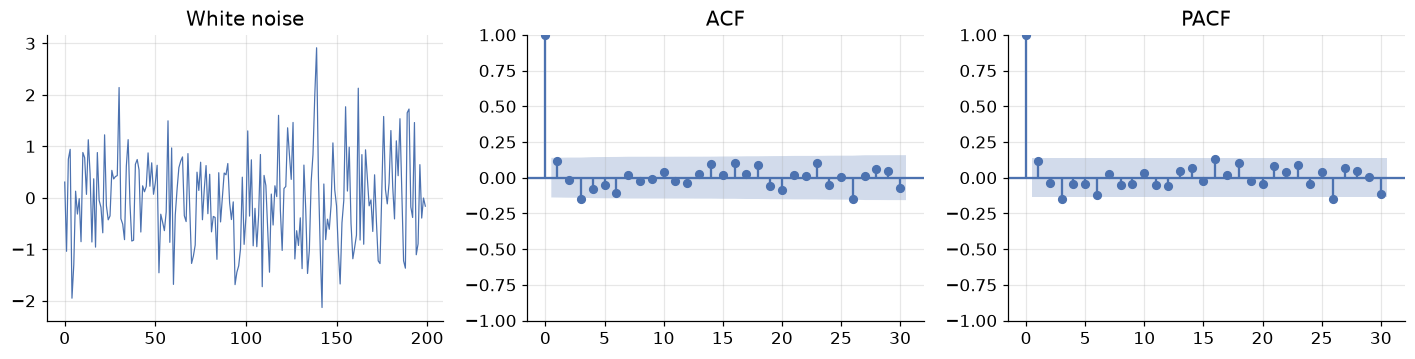

In [14]:
white_noise = pd.Series(rng.normal(0, 1, 200))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(white_noise, lw=0.8, color="C0")
axes[0].set_title("White noise")
plot_acf(white_noise, lags=30, ax=axes[1], title="ACF")
plot_pacf(white_noise, lags=30, ax=axes[2], title="PACF", method="ywm")
plt.tight_layout()
plt.show()

**White noise** — independent draws with constant mean and variance — is the only series that is
*completely unforecastable*, and it is the benchmark for everything else. Its ACF is essentially zero at
every lag beyond zero (lag 0 is always exactly 1: a series correlates perfectly with itself).

The shaded blue band is the **95% confidence region**, roughly $\pm 1.96/\sqrt{n}$. Spikes inside it are
indistinguishable from zero. A couple of the thirty spikes poke outside — expected, since a 95% band
misses 1 in 20 by construction. **Do not chase isolated spikes; look for patterns.**

This gives us the sharpest possible statement of what modelling is for:

> **Goal: extract structure until the residuals are white noise.** Any structure left in the residuals is
> forecastable signal you failed to capture.

Now the real series.

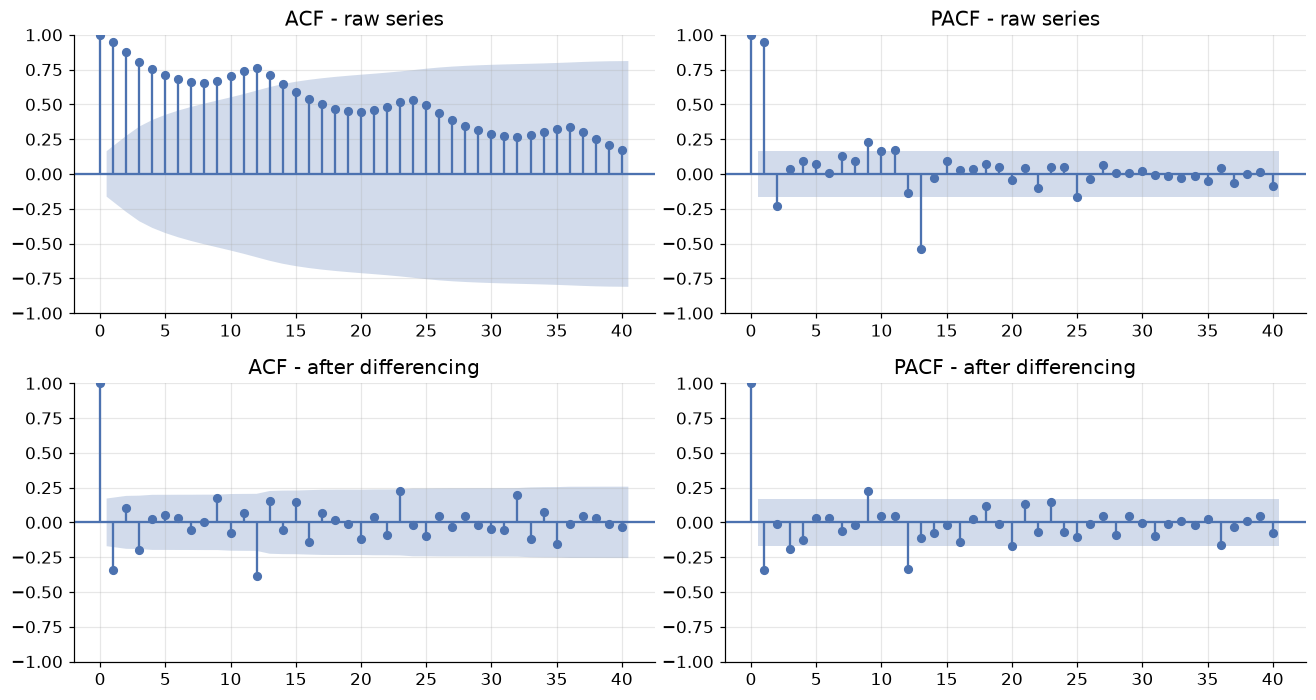

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))

plot_acf(passengers, lags=40, ax=axes[0, 0], title="ACF - raw series")
plot_pacf(passengers, lags=40, ax=axes[0, 1], title="PACF - raw series", method="ywm")

stationary = np.log(passengers).diff().diff(12).dropna()
plot_acf(stationary, lags=40, ax=axes[1, 0], title="ACF - after differencing")
plot_pacf(stationary, lags=40, ax=axes[1, 1], title="PACF - after differencing", method="ywm")

plt.tight_layout()
plt.show()

Compare the top and bottom rows — this contrast is the single most useful diagnostic skill in the module.

**Top row (raw series).** The ACF decays *very* slowly, staying far outside the confidence band past lag
40. That slow linear decay is the unmistakable **signature of a trend**: because the series is drifting,
every observation is above average at the same time as its neighbours, so everything correlates with
everything. Superimposed on the decay is a ripple peaking at lags 12, 24, 36 — the **signature of
seasonality** with period 12. The PACF, meanwhile, shows one huge spike at lag 1 and little after: nearly
all of that impressive-looking correlation is *indirect*, inherited through lag 1.

**Bottom row (differenced series).** The forest of significant spikes is gone. What remains are a few
isolated, interpretable spikes — notably at lag 1 and lag 12. These are the residual structure that an
ARIMA model will capture, and in Module 12 you will read exactly these two spikes off the plot to choose
the model orders. For now, the lesson is simpler:

| What you see in the ACF | What it means |
|---|---|
| Slow, near-linear decay | Trend — the series needs differencing |
| Spikes at $k, 2k, 3k, \dots$ | Seasonality with period $k$ |
| Everything inside the band | White noise — nothing left to model |
| One large negative spike at lag 1 | Possible **over**-differencing |
| A few significant spikes near lag 0 | Short-memory structure: the AR/MA models of Module 12 |

In [16]:
# A quick numerical confirmation of what the eye reported
acf_raw = acf(passengers, nlags=24)
acf_diff = acf(stationary, nlags=24)

print("lag    ACF(raw)   ACF(differenced)")
for k in [1, 2, 6, 11, 12, 13, 24]:
    print(f"{k:>3}    {acf_raw[k]:>7.3f}   {acf_diff[k]:>10.3f}")

band = 1.96 / np.sqrt(len(stationary))
print(f"\n95% band for the differenced series: +/-{band:.3f}")
print(f"Significant lags remaining: "
      f"{[k for k in range(1, 25) if abs(acf_diff[k]) > band]}")

lag    ACF(raw)   ACF(differenced)
  1      0.948       -0.341
  2      0.876        0.105
  6      0.682        0.031
 11      0.743        0.064
 12      0.760       -0.387
 13      0.713        0.152
 24      0.532       -0.018

95% band for the differenced series: +/-0.171
Significant lags remaining: [1, 3, 9, 12, 23]


---
## 7. Splitting time, and four baselines you must beat

### Splitting without cheating

The rule is absolute: **the test set is the most recent block, and the model never sees it.** No
shuffling, no random selection.

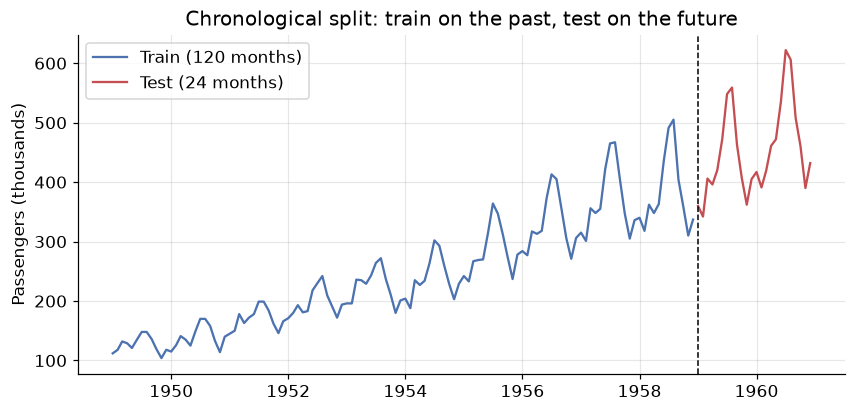

Train: Jan 1949 to Dec 1958
Test:  Jan 1959 to Dec 1960


In [17]:
TEST_MONTHS = 24                       # hold out the final two years
train, test = passengers[:-TEST_MONTHS], passengers[-TEST_MONTHS:]

fig, ax = plt.subplots()
ax.plot(train, color="C0", label=f"Train ({len(train)} months)")
ax.plot(test, color="C3", label=f"Test ({len(test)} months)")
ax.axvline(test.index[0], color="black", ls="--", lw=1)
ax.set_title("Chronological split: train on the past, test on the future")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
plt.show()

print(f"Train: {train.index.min():%b %Y} to {train.index.max():%b %Y}")
print(f"Test:  {test.index.min():%b %Y} to {test.index.max():%b %Y}")

Choose the test length to match the **forecast horizon you actually care about**. If the business needs
a 12-month-ahead forecast, testing on 12 months answers the real question; testing on 3 months flatters
the model, because forecast error grows with horizon.

For model *selection* — comparing candidates — the more rigorous approach is **rolling-origin
cross-validation**: forecast from origin $t$, then $t+1$, then $t+2$, each time training only on data up
to that origin, and average the errors. scikit-learn's `TimeSeriesSplit` implements exactly this.

### The four baselines

Before any sophisticated model, you need to know what "trivially easy" scores. These four are the
standard benchmarks, and a model that cannot beat them is not worth deploying.

| Method | Forecast $\hat{y}_{T+h}$ | Idea |
|---|---|---|
| **Mean** | $\bar{y}$ | Everything reverts to the historical average |
| **Naive** | $y_T$ | Tomorrow equals today |
| **Seasonal naive** | $y_{T+h-m}$ | This July equals last July |
| **Drift** | $y_T + h \cdot \frac{y_T - y_1}{T-1}$ | Naive plus the average historical slope |

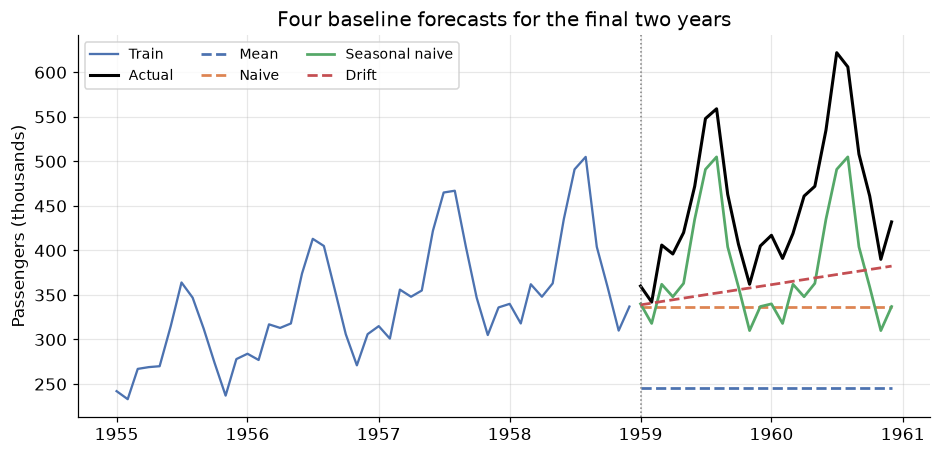

In [18]:
h = len(test)
m = 12                                            # seasonal period
idx = test.index

forecasts = {
    "Mean":           pd.Series(train.mean(), index=idx),
    "Naive":          pd.Series(train.iloc[-1], index=idx),
    "Seasonal naive": pd.Series(train.iloc[-m:].values[np.arange(h) % m], index=idx),
    "Drift":          pd.Series(train.iloc[-1] + np.arange(1, h + 1)
                                * (train.iloc[-1] - train.iloc[0]) / (len(train) - 1), index=idx),
}

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(train[-48:], color="C0", label="Train")
ax.plot(test, color="black", lw=2, label="Actual")
for (name, fc), style in zip(forecasts.items(), ["--", "--", "-", "--"]):
    ax.plot(fc, ls=style, lw=1.8, label=name)
ax.axvline(idx[0], color="grey", ls=":", lw=1)
ax.set_title("Four baseline forecasts for the final two years")
ax.set_ylabel("Passengers (thousands)")
ax.legend(ncol=3, fontsize=9)
plt.show()

The picture is decisive. **Mean** is hopeless — it ignores the trend entirely and forecasts a level the
series left behind years ago. **Naive** is a flat line at the last observed value; it at least starts in
the right neighbourhood, but knows nothing of seasonality. **Drift** continues the average historical
slope, which captures the growth but none of the annual pattern. **Seasonal naive** is the only one whose
forecast has the right *shape*, because it simply replays the last twelve months.

For any seasonal series, **seasonal naive is the baseline to beat** — and it is a genuinely tough one.

---
## 8. Measuring forecast error

Which of those four is best? "It looks better" is not an answer. Let $e_t = y_t - \hat{y}_t$ be the
forecast error at time $t$.

$$\text{MAE} = \frac{1}{h}\sum |e_t| \qquad \text{RMSE} = \sqrt{\frac{1}{h}\sum e_t^2} \qquad
\text{MAPE} = \frac{100}{h}\sum \left|\frac{e_t}{y_t}\right| \qquad
\text{MASE} = \frac{\text{MAE}}{\text{MAE}_{\text{seasonal naive, in-sample}}}$$

You met MAE and RMSE in the Evaluation Metrics module and they behave identically here: both are in the
units of the data, and RMSE punishes large errors harder because of the square. Two are new and specific
to forecasting.

**MAPE** expresses error as a *percentage*, which makes it comparable across series measured in different
units — the reason it dominates business reporting. It has two real flaws: it explodes when $y_t$ is near
zero, and it is asymmetric, penalising over-forecasts more heavily than under-forecasts.

**MASE** fixes the comparability problem properly by dividing by the error a *seasonal naive* model makes
on the training data. This makes the interpretation beautifully direct:

> **MASE compares your errors to seasonal naive's, on a unit-free scale. Lower is better, and 1 is the
> reference point.** (The output below shows why that reference point needs care — read the commentary
> after the table.)

In [19]:
def mase(y_true, y_pred, y_train, m=12):
    """Mean Absolute Scaled Error: MAE relative to in-sample seasonal-naive MAE."""
    naive_mae = np.mean(np.abs(y_train[m:].values - y_train[:-m].values))
    return np.mean(np.abs(y_true - y_pred)) / naive_mae

def evaluate(y_true, y_pred, y_train, m=12):
    e = y_true - y_pred
    return {
        "MAE":  np.mean(np.abs(e)),
        "RMSE": np.sqrt(np.mean(e ** 2)),
        "MAPE": np.mean(np.abs(e / y_true)) * 100,
        "MASE": mase(y_true, y_pred, y_train, m),
    }

scores = pd.DataFrame({name: evaluate(test, fc, train) for name, fc in forecasts.items()}).T
scores = scores.sort_values("MASE")
print(scores.round(2).to_string())

                   MAE    RMSE   MAPE  MASE
Seasonal naive   71.25   76.99  15.52  2.49
Drift            91.62  115.70  18.41  3.21
Naive           115.25  137.33  23.58  4.03
Mean            206.34  219.44  44.23  7.22


Seasonal naive wins on every metric — MAE of 71 thousand passengers, MAPE of 16%, and it is roughly three
times better than the mean baseline. This row is the target: **everything you build in Modules 11 and 12
will be measured against it.**

The MASE column deserves a careful reading, because a value of 2.49 looks alarming next to the "MASE < 1
is good" rule. There is no contradiction — the denominator and numerator are measured on *different
tasks*. The denominator is how well seasonal naive does **one season ahead, inside the training data**
(MAE ≈ 28.6); the numerator is how well it does **up to 24 months ahead, on data it has never seen**
(MAE ≈ 71.3). Forecasting two years into a growing series is genuinely about 2.5 times harder than
predicting the next season in-sample. So MASE > 1 here does *not* mean the method is broken; it means the
test task is harder than the reference task. The rule of thumb applies cleanly when you compare *two
models on the same test set* — and there, lower is still better.

One more diagnostic, and it is the one people skip: **look at the residuals of your forecast, not just
the score.**

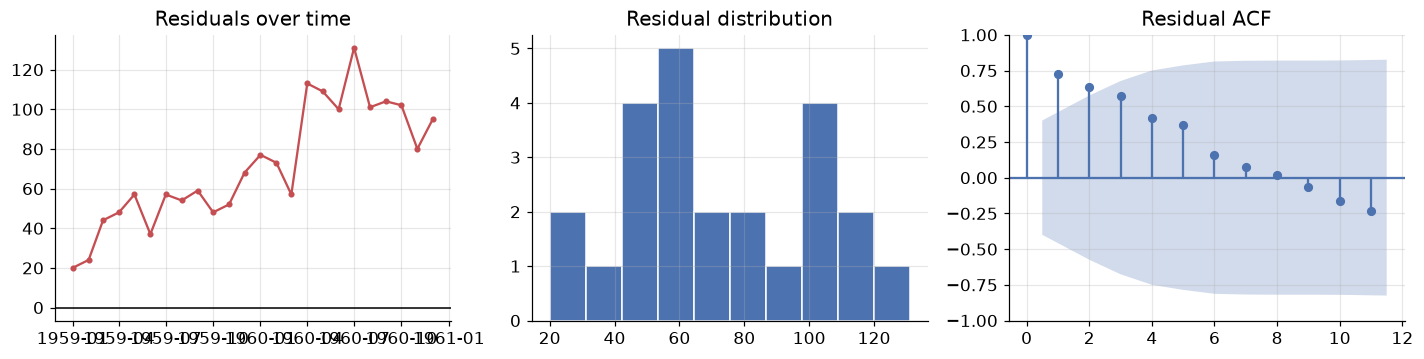

Mean residual: +71.2  <- systematic bias if far from 0


In [20]:
best = forecasts["Seasonal naive"]
resid = test - best

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(resid, color="C3", marker="o", ms=3)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Residuals over time")
axes[1].hist(resid, bins=10, color="C0", edgecolor="white")
axes[1].set_title("Residual distribution")
plot_acf(resid, lags=11, ax=axes[2], title="Residual ACF")
plt.tight_layout()
plt.show()

print(f"Mean residual: {resid.mean():+.1f}  <- systematic bias if far from 0")

The mean residual is $+71$ thousand passengers — strongly positive, and note that it is essentially equal
to the MAE, which means **almost every single residual is positive**. Seasonal naive
**systematically under-forecasts**. That is exactly what we should expect: replaying last year ignores
the fact that the series grows every year, so every forecast lands low by roughly one year's growth.

This is the payoff of residual diagnostics over a single score. The number told us seasonal naive was
best; the residuals told us *how it fails* — a missing trend — and therefore what to fix. A method that
combines seasonal replay **with** a trend would beat it. That method is Holt-Winters, and it is the first
thing you will build in Module 11.

---
## 9. Your turn

Add cells below each exercise. Exercises 4 and 5 consolidate the big ideas.

**Exercise 1 — A different series, the same reading.**
Load the sunspot data with `sm.datasets.sunspots.load_pandas().data` (annual sunspot counts, 1700–2008)
and plot it with its ACF. Sunspots have a famous ~11-year rhythm. Is that **seasonal** or **cyclical**
by the Section 3 definition — and what in the ACF plot supports your answer?

**Exercise 2 — Does the decomposition model matter?**
Rerun `seasonal_decompose` on Air Passengers with `model="additive"`. Plot the residual panels of the
additive and multiplicative versions side by side. Which residual looks more like white noise, and how
does the *shape* of the additive residual reveal that the wrong model was chosen?

**Exercise 3 — How much differencing is too much?**
Take `np.log(passengers)` and difference it once, twice, and three times. For each, report the ADF
p-value, the **standard deviation** of the result, and the lag-1 autocorrelation. The variance should
reach a minimum and then *increase* — find where, and explain why that identifies over-differencing.

**Exercise 4 — Build a fifth baseline.**
Seasonal naive fails because it ignores growth (Section 8). Implement **seasonal naive with drift**:
take the seasonal-naive forecast and add the average annual increase estimated from the training data.
Score it with `evaluate()` and add it to the table. Does it beat seasonal naive, and is its mean
residual closer to zero?

**Exercise 5 — Honest validation.**
The Section 7 split gives *one* estimate of error from *one* origin. Use
`sklearn.model_selection.TimeSeriesSplit(n_splits=5)` to run rolling-origin validation of the four
baselines, and report mean ± std of MASE across folds. Does the ranking from Section 8 survive? What does
the spread across folds tell you that a single split cannot?

---
## 10. If you remember nothing else

1. **Order is the signal.** Time series data violates the i.i.d. assumption that every earlier module
   relied on. Shuffled splits and k-fold CV leak the future and must be replaced by chronological splits
   and rolling-origin validation.

2. **Every series is trend + seasonality + cycle + noise.** Seasonality has a *fixed, known* period
   (tied to the calendar); a cycle does not. If the seasonal swings widen as the level rises the
   composition is **multiplicative** — and $\log$ turns multiplicative into additive, which is why the
   log transform is the most useful single move in this field.

3. **Decompose before you model, and read the residual panel.** `seasonal_decompose` is the classical
   recipe (moving-average trend, averaged seasonal profile); **STL** is the robust modern version that
   keeps all observations and lets the seasonal shape evolve. Structure left in the residual is structure
   your model missed.

4. **Stationarity is the licence to forecast.** Constant mean, constant variance, lag-only covariance —
   the formal way of saying "the past is a fair guide to the future". Confirm with **ADF** ($H_0$ =
   non-stationary, so want p < 0.05) *and* **KPSS** ($H_0$ = stationary, so want p > 0.05). Logs
   stabilise variance; **differencing** removes trend; **seasonal differencing** removes season.

5. **The ACF/PACF plot is the fingerprint.** ACF = total correlation at lag $k$; PACF = direct
   correlation with the intervening lags removed. Slow decay means trend, spikes at multiples of $m$
   mean seasonality, everything inside the band means white noise. The goal of modelling is residuals
   that look like that last case.

6. **Beat the baseline or go home.** Mean, naive, seasonal naive and drift cost nothing to compute. For
   seasonal data, seasonal naive is a hard benchmark. **MASE** scores against it on a unit-free scale;
   just remember its denominator is *in-sample one-season-ahead* error, so compare models to each other
   on the same test set rather than reading the value 1 as a magic threshold. And always inspect the
   **residuals**, not just the score — the score ranked our baselines, the residuals told us *why* the
   winner fails (a missing trend), which is what tells you what to build next.

---
## 11. Further reading and glossary

### Further reading

- Hyndman & Athanasopoulos, [*Forecasting: Principles and Practice*](https://otexts.com/fpp3/) — free
  online and the standard reference for this entire section of the course. Chapters 2 (graphics),
  3 (decomposition) and 5 (the toolbox) cover this module, and MASE is their invention.
- [statsmodels time series analysis guide](https://www.statsmodels.org/stable/tsa.html) — the API
  reference for everything we imported, with worked examples.
- Rob Hyndman, [Why every statistician should know about cross-validation](https://robjhyndman.com/hyndsight/tscv/)
  — a short, sharp piece on why time series validation must roll forward.
- Cleveland et al., [STL: A Seasonal-Trend Decomposition Procedure Based on Loess](https://www.wessa.net/download/stl.pdf)
  — the original 1990 paper, unusually readable for a methods paper.
- [Pandas time series documentation](https://pandas.pydata.org/docs/user_guide/timeseries.html) — the
  full catalogue of offset aliases, resampling rules and window functions.

### Glossary

| Term | Meaning |
|---|---|
| **Time series** | Observations indexed by time, where the ordering carries information |
| **Trend ($T_t$)** | Long-run movement in the level of the series |
| **Seasonality ($S_t$)** | Repeating pattern of fixed, known period $m$ |
| **Cyclical ($C_t$)** | Rises and falls of no fixed period, usually multi-year |
| **Irregular ($e_t$)** | Unexplained residual variation |
| **Additive / multiplicative** | Components combine by $+$ (constant swings) or $\times$ (proportional swings) |
| **Decomposition** | Splitting a series into trend, seasonal and residual components |
| **STL** | Seasonal-Trend decomposition using LOESS; robust, keeps all observations |
| **Stationarity** | Constant mean and variance; covariance depends only on the lag |
| **Unit root** | The condition making a series wander without reverting; what ADF tests for |
| **ADF test** | $H_0$ = non-stationary; p < 0.05 supports stationarity |
| **KPSS test** | $H_0$ = stationary; p > 0.05 supports stationarity |
| **Differencing ($\nabla y_t$)** | $y_t - y_{t-1}$; removes trend. Seasonal: $y_t - y_{t-m}$ |
| **Autocorrelation (ACF)** | Correlation of the series with a lagged copy of itself |
| **Partial autocorrelation (PACF)** | Same, with the effect of intervening lags removed |
| **Correlogram** | The ACF plot, with its $\pm 1.96/\sqrt{n}$ significance band |
| **White noise** | Uncorrelated, constant-mean, constant-variance series; unforecastable |
| **Lag** | The gap $k$ between an observation and an earlier one |
| **Naive / seasonal naive** | Forecast the last value / the value one season ago |
| **Drift** | Naive plus the average historical slope |
| **MAPE** | Mean absolute percentage error; unit-free but unstable near zero |
| **MASE** | MAE scaled by in-sample seasonal-naive MAE; unit-free, so comparable across series |
| **Rolling-origin CV** | Validation where the training window only grows forwards in time |